# HLL++ precision mismatch: recoverable full matrix

Analisi della matrice completa di coppie di precisione per il caso `recoverable`, con una sola direzione per coppia e senza strategia `reject`.

In [1]:
from __future__ import annotations

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / 'README.md').exists() and (path / 'results').exists():
            return path
    raise RuntimeError('Repository root non trovata')


REPO = find_repo_root(Path.cwd().resolve())
RESULTS_ROOT = REPO / 'results'
OUT_DIR = REPO / 'thesis' / 'figures' / 'results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_GLOB = 'merge_hpp_precision_mismatch_recoverable_full_*_d_*/**/results_merge_heterogeneous.csv'
PAIR_GROUP_ORDER = [
    '8 vs 10', '8 vs 12', '8 vs 14', '8 vs 16', '8 vs 18',
    '10 vs 12', '10 vs 14', '10 vs 16', '10 vs 18',
    '12 vs 14', '12 vs 16', '12 vs 18',
    '14 vs 16', '14 vs 18', '16 vs 18',
]
STRATEGY_ORDER = ['unsafe_naive_merge', 'reduce_then_merge']
RHO_ORDER = [1, 10, 100]

print('REPO:', REPO)
print('RESULTS_ROOT:', RESULTS_ROOT)
print('OUT_DIR:', OUT_DIR)
print('RESULTS_GLOB:', RESULTS_GLOB)


REPO: /home/daniele/Dev/satp-cpp
RESULTS_ROOT: /home/daniele/Dev/satp-cpp/results
OUT_DIR: /home/daniele/Dev/satp-cpp/thesis/figures/results
RESULTS_GLOB: merge_hpp_precision_mismatch_recoverable_full_*_d_*/**/results_merge_heterogeneous.csv


In [2]:
def parse_meta(path: Path) -> dict:
    rel = path.relative_to(RESULTS_ROOT)
    namespace = rel.parts[0]
    hash_cfg = rel.parts[3]
    params = rel.parts[4]

    m_ns = re.match(r'merge_hpp_precision_mismatch_recoverable_full_(\d+)_(\d+)_d_(\d+)$', namespace)
    if not m_ns:
        raise ValueError(f'Namespace non riconosciuto: {namespace}')
    left_k_ns, right_k_ns, d_raw = m_ns.groups()

    m_hash = re.match(r'left_(.+?)_seed_(\d+)_right_(.+?)_seed_(\d+)$', hash_cfg)
    if not m_hash:
        raise ValueError(f'Configurazione hash non riconosciuta: {hash_cfg}')
    left_hash, left_seed, right_hash, right_seed = m_hash.groups()

    m_params = re.match(r'left_k_(\d+)_right_k_(\d+)_strategy_(.+)$', params)
    if not m_params:
        raise ValueError(f'Parametri non riconosciuti: {params}')
    left_k, right_k, strategy = m_params.groups()

    d = int(d_raw)
    left_k = int(left_k)
    right_k = int(right_k)
    rho = int(round(10_000_000 / d))
    pair_group = f'{min(left_k, right_k)} vs {max(left_k, right_k)}'

    if int(left_k_ns) != left_k or int(right_k_ns) != right_k:
        raise ValueError(f'Namespace e path non coerenti: {namespace} / {params}')

    return {
        'namespace': namespace,
        'd': d,
        'rho': rho,
        'left_hash': left_hash,
        'right_hash': right_hash,
        'left_hash_seed': int(left_seed),
        'right_hash_seed': int(right_seed),
        'left_k': left_k,
        'right_k': right_k,
        'pairing': f'{left_k}->{right_k}',
        'pair_group': pair_group,
        'strategy': strategy,
    }


frames = []
for csv_path in sorted(RESULTS_ROOT.glob(RESULTS_GLOB)):
    meta = parse_meta(csv_path)
    frame = pd.read_csv(csv_path)
    for key, value in meta.items():
        frame[key] = value
    frames.append(frame)

if not frames:
    raise RuntimeError('Nessun CSV trovato per la campagna recoverable full')

df = pd.concat(frames, ignore_index=True)
df['pair_group'] = pd.Categorical(df['pair_group'], categories=PAIR_GROUP_ORDER, ordered=True)
df['strategy'] = pd.Categorical(df['strategy'], categories=STRATEGY_ORDER, ordered=True)
df['degradation_ratio'] = np.where(
    df['error_serial_rel_exact'] > 0,
    df['error_merge_rel_exact'] / df['error_serial_rel_exact'],
    np.nan,
)
df['baseline_gap_rel'] = (df['estimate_merge'] - df['baseline_homogeneous']).abs() / df['exact_union']

print('files:', len(frames))
print('rows:', len(df))
print('pair groups:', sorted(df['pair_group'].dropna().unique().tolist()))
print('strategies:', sorted(df['strategy'].dropna().unique().tolist()))
print('validities:', sorted(df['validity'].unique().tolist()))
print('d values:', sorted(df['d'].unique().tolist()))
print('rho values:', sorted(df['rho'].unique().tolist()))

display(df.head())


files: 90
rows: 2250
pair groups: ['10 vs 12', '10 vs 14', '10 vs 16', '10 vs 18', '12 vs 14', '12 vs 16', '12 vs 18', '14 vs 16', '14 vs 18', '16 vs 18', '8 vs 10', '8 vs 12', '8 vs 14', '8 vs 16', '8 vs 18']
strategies: ['reduce_then_merge', 'unsafe_naive_merge']
validities: ['recoverable']
d values: [100000, 1000000, 10000000]
rho values: [1, 10, 100]


,algorithm,mode,pairs,sample_size,pair_index,dataset_seed,left_hash,right_hash,left_hash_seed,right_hash_seed,...,delta_vs_baseline,namespace,d,rho,left_k,right_k,pairing,pair_group,degradation_ratio,baseline_gap_rel
0,HyperLogLog++,merge_heterogeneous,25,10000000,0,21041998,xxhash64,xxhash64,21041998,21041998,...,0,merge_hpp_precision_mismatch_recoverable_full_...,100000,100,10,12,10->12,10 vs 12,1.0,0.0
1,HyperLogLog++,merge_heterogeneous,25,10000000,1,21041998,xxhash64,xxhash64,21041998,21041998,...,0,merge_hpp_precision_mismatch_recoverable_full_...,100000,100,10,12,10->12,10 vs 12,1.0,0.0
2,HyperLogLog++,merge_heterogeneous,25,10000000,2,21041998,xxhash64,xxhash64,21041998,21041998,...,0,merge_hpp_precision_mismatch_recoverable_full_...,100000,100,10,12,10->12,10 vs 12,1.0,0.0
3,HyperLogLog++,merge_heterogeneous,25,10000000,3,21041998,xxhash64,xxhash64,21041998,21041998,...,0,merge_hpp_precision_mismatch_recoverable_full_...,100000,100,10,12,10->12,10 vs 12,1.0,0.0
4,HyperLogLog++,merge_heterogeneous,25,10000000,4,21041998,xxhash64,xxhash64,21041998,21041998,...,0,merge_hpp_precision_mismatch_recoverable_full_...,100000,100,10,12,10->12,10 vs 12,1.0,0.0


In [3]:
summary_runs = (
    df.groupby(['pairing', 'pair_group', 'strategy', 'validity', 'd', 'rho'], dropna=False)
      .agg(
          pairs=('pair_index', 'size'),
          merge_rel_mean=('error_merge_rel_exact', 'mean'),
          merge_rel_median=('error_merge_rel_exact', 'median'),
          merge_rel_max=('error_merge_rel_exact', 'max'),
          serial_rel_mean=('error_serial_rel_exact', 'mean'),
          baseline_gap_abs_mean=('delta_vs_baseline', 'mean'),
          baseline_gap_abs_max=('delta_vs_baseline', 'max'),
          baseline_gap_rel_mean=('baseline_gap_rel', 'mean'),
          degradation_ratio_mean=('degradation_ratio', 'mean'),
          merge_eq_serial_all=('estimate_merge', lambda s: ((s == df.loc[s.index, 'estimate_serial']) | (s.isna() & df.loc[s.index, 'estimate_serial'].isna())).all()),
          merge_eq_baseline_all=('estimate_merge', lambda s: ((s == df.loc[s.index, 'baseline_homogeneous']) | (s.isna() & df.loc[s.index, 'baseline_homogeneous'].isna())).all()),
      )
      .reset_index()
      .sort_values(['pair_group', 'strategy', 'rho'])
)

summary_pair_group = (
    df.groupby(['pair_group', 'strategy', 'd', 'rho'], dropna=False)
      .agg(
          merge_rel_mean=('error_merge_rel_exact', 'mean'),
          serial_rel_mean=('error_serial_rel_exact', 'mean'),
          baseline_gap_rel_mean=('baseline_gap_rel', 'mean'),
          degradation_ratio_mean=('degradation_ratio', 'mean'),
      )
      .reset_index()
      .sort_values(['pair_group', 'strategy', 'rho'])
)

summary_global = (
    df.groupby(['strategy', 'validity'], dropna=False)
      .agg(
          pairs=('pair_index', 'size'),
          merge_rel_mean=('error_merge_rel_exact', 'mean'),
          merge_rel_median=('error_merge_rel_exact', 'median'),
          merge_rel_max=('error_merge_rel_exact', 'max'),
          serial_rel_mean=('error_serial_rel_exact', 'mean'),
          baseline_gap_abs_mean=('delta_vs_baseline', 'mean'),
          baseline_gap_abs_max=('delta_vs_baseline', 'max'),
          degradation_ratio_mean=('degradation_ratio', 'mean'),
      )
      .reset_index()
      .sort_values(['strategy'])
)

consistency_checks = pd.DataFrame([
    {
        'check': 'reduce_then_merge == serial for all rows',
        'value': bool(df.query("strategy == 'reduce_then_merge'")['estimate_merge'].eq(df.query("strategy == 'reduce_then_merge'")['estimate_serial']).all()),
    },
    {
        'check': 'reduce_then_merge == baseline for all rows',
        'value': bool(df.query("strategy == 'reduce_then_merge'")['estimate_merge'].eq(df.query("strategy == 'reduce_then_merge'")['baseline_homogeneous']).all()),
    },
])

summary_runs.to_csv(RESULTS_ROOT / 'merge_hpp_precision_mismatch_recoverable_full_summary_runs.csv', index=False)
summary_pair_group.to_csv(RESULTS_ROOT / 'merge_hpp_precision_mismatch_recoverable_full_pair_groups.csv', index=False)
summary_global.to_csv(RESULTS_ROOT / 'merge_hpp_precision_mismatch_recoverable_full_summary_global.csv', index=False)
consistency_checks.to_csv(RESULTS_ROOT / 'merge_hpp_precision_mismatch_recoverable_full_consistency_checks.csv', index=False)

display(summary_runs.head())
display(summary_global)
display(consistency_checks)


,pairing,pair_group,strategy,validity,d,rho,pairs,merge_rel_mean,merge_rel_median,merge_rel_max,serial_rel_mean,baseline_gap_abs_mean,baseline_gap_abs_max,baseline_gap_rel_mean,degradation_ratio_mean,merge_eq_serial_all,merge_eq_baseline_all
62,8->10,8 vs 10,unsafe_naive_merge,recoverable,10000000,1,25,0.759220,0.759220,0.759220,0.040880,8001000.00,8001000,0.800100,18.571918,False,False
61,8->10,8 vs 10,unsafe_naive_merge,recoverable,1000000,10,25,0.053795,0.053120,0.157845,0.058652,107839.20,254269,0.056759,1.696151,False,False
60,8->10,8 vs 10,unsafe_naive_merge,recoverable,100000,100,25,0.053534,0.047839,0.142698,0.052945,11166.84,27246,0.056114,2.855632,False,False
65,8->10,8 vs 10,reduce_then_merge,recoverable,10000000,1,25,0.040880,0.040880,0.040880,0.040880,0.00,0,0.000000,1.000000,True,True
64,8->10,8 vs 10,reduce_then_merge,recoverable,1000000,10,25,0.058652,0.042838,0.145536,0.058652,0.00,0,0.000000,1.000000,True,True


,strategy,validity,pairs,merge_rel_mean,merge_rel_median,merge_rel_max,serial_rel_mean,baseline_gap_abs_mean,baseline_gap_abs_max,degradation_ratio_mean
0,unsafe_naive_merge,recoverable,1125,0.328528,0.053454,1.102939,0.025989,3.084116e+06,10918566,27.696217
1,reduce_then_merge,recoverable,1125,0.025989,0.016417,0.145536,0.025989,0.000000e+00,0,1.000000


,check,value
0,reduce_then_merge == serial for all rows,True
1,reduce_then_merge == baseline for all rows,True


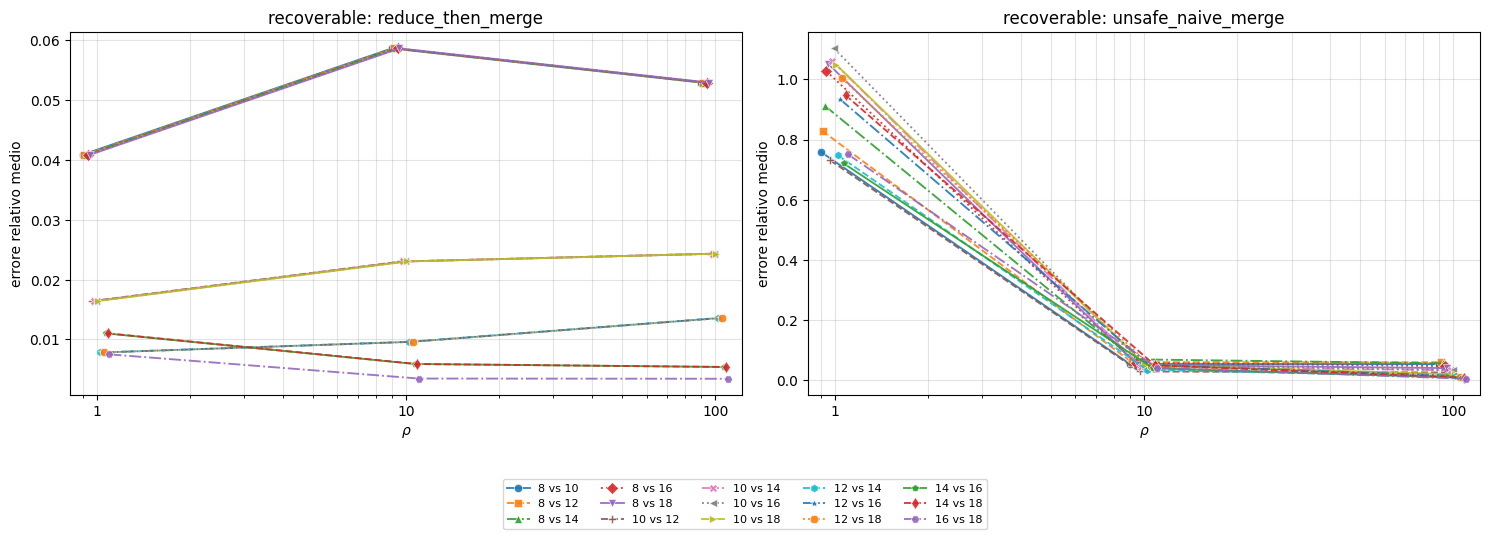

In [4]:
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '<', '>', 'h', '*', '8', 'p', 'd', 'H']
LINESTYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.']
JITTER_FACTORS = dict(zip(PAIR_GROUP_ORDER, np.geomspace(0.90, 1.10, len(PAIR_GROUP_ORDER))))


def plot_strategy_lines(ax, data: pd.DataFrame, strategy: str, title: str) -> None:
    strat = data[data['strategy'] == strategy].copy()
    for idx, pair_group in enumerate(PAIR_GROUP_ORDER):
        sub = strat[strat['pair_group'] == pair_group].sort_values('rho')
        if sub.empty:
            continue
        x = sub['rho'].to_numpy(dtype=float) * JITTER_FACTORS[pair_group]
        ax.plot(
            x,
            sub['merge_rel_mean'],
            marker=MARKERS[idx % len(MARKERS)],
            linestyle=LINESTYLES[idx % len(LINESTYLES)],
            linewidth=1.35,
            markersize=6.0,
            alpha=0.9,
            markeredgecolor='white',
            markeredgewidth=0.45,
            label=pair_group,
        )
    ax.set_xscale('log')
    ax.set_xticks(RHO_ORDER)
    ax.set_xticklabels([str(v) for v in RHO_ORDER])
    ax.set_xlim(0.82, 122)
    ax.set_xlabel(r'$\rho$')
    ax.set_ylabel('errore relativo medio')
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.35)


fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
plot_strategy_lines(axes[0], summary_pair_group, 'reduce_then_merge', 'recoverable: reduce_then_merge')
plot_strategy_lines(axes[1], summary_pair_group, 'unsafe_naive_merge', 'recoverable: unsafe_naive_merge')

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(rect=(0, 0.08, 1, 1))
fig.savefig(OUT_DIR / 'merge_hpp_precision_mismatch_recoverable_full_overview.png', dpi=200, bbox_inches='tight')
fig.savefig(OUT_DIR / 'merge_hpp_precision_mismatch_recoverable_full_overview.pdf', bbox_inches='tight')
plt.show()


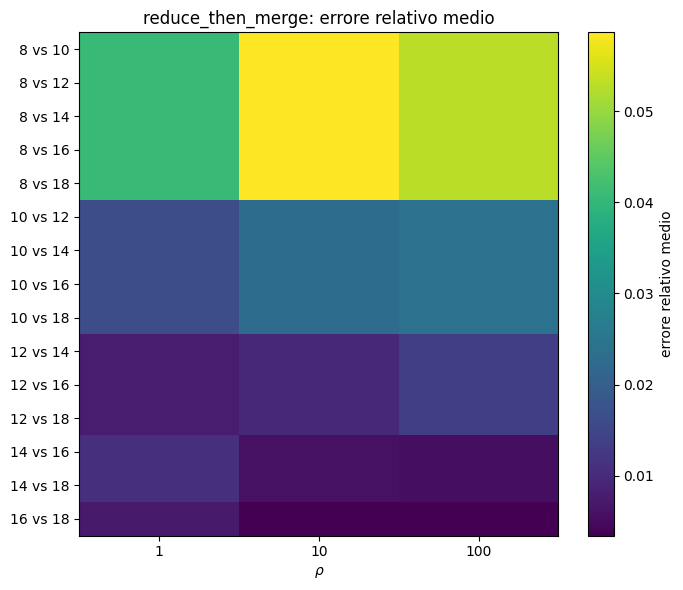

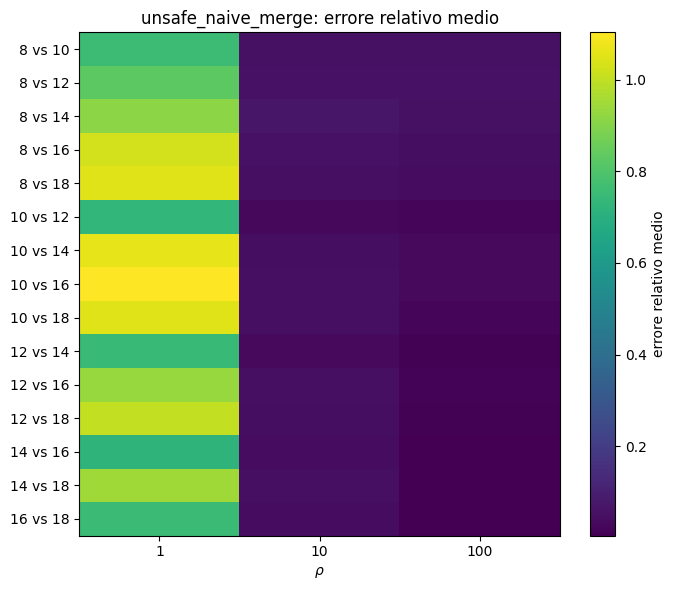

In [5]:
def plot_heatmap(strategy: str, out_stem: str, title: str) -> None:
    matrix = (
        summary_pair_group[summary_pair_group['strategy'] == strategy]
        .pivot(index='pair_group', columns='rho', values='merge_rel_mean')
        .reindex(PAIR_GROUP_ORDER)
        .reindex(columns=RHO_ORDER)
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(matrix.values, aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(matrix.columns)), labels=matrix.columns)
    ax.set_yticks(range(len(matrix.index)), labels=matrix.index)
    ax.set_xlabel(r'$\rho$')
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('errore relativo medio')
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'{out_stem}.png', dpi=200, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'{out_stem}.pdf', bbox_inches='tight')
    plt.show()


plot_heatmap('reduce_then_merge', 'merge_hpp_precision_mismatch_recoverable_full_reduce_heatmap', 'reduce_then_merge: errore relativo medio')
plot_heatmap('unsafe_naive_merge', 'merge_hpp_precision_mismatch_recoverable_full_unsafe_heatmap', 'unsafe_naive_merge: errore relativo medio')
